# EXP/0413 — Seller Price Function Analysis: `anchor_high`

**Hypothesis**: The seller's next price $s_t$ is a piecewise-linear function of
the buyer's current price $m_t$ and the seller's previous price $s_{t-1}$,
with breakpoints at the seller's valuation floor $v$ and the acceptance threshold $s_{t-1}$.

$$s_t = \begin{cases}
\alpha_0 + \alpha_s \cdot s_{t-1} & m_t < v \quad\text{(floor regime)} \\
\beta_0 + \beta_m \cdot m_t + \beta_s \cdot s_{t-1} & v \leq m_t \leq s_{t-1} \quad\text{(negotiation)} \\
\gamma_0 + \gamma_m \cdot m_t & m_t > s_{t-1} \quad\text{(acceptance)}
\end{cases}$$

---

## S0. Setup

In [2]:
import json, sys, glob, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
%matplotlib inline
plt.rcParams['figure.dpi'] = 130
plt.rcParams['figure.figsize'] = (10, 5)
warnings.filterwarnings('ignore')

STRATEGY = "anchor_high"
SLABEL = "Anchor High"
RESULTS_DIR = Path("results") / STRATEGY

def ols(X, y):
    n, p = X.shape
    b, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    yh = X @ b; r = y - yh
    rmse = float(np.sqrt(np.mean(r**2)))
    ss_r = float(np.sum(r**2)); ss_t = float(np.sum((y - np.mean(y))**2))
    r2 = 1 - ss_r/ss_t if ss_t > 1e-12 else 1.0
    dof = max(n-p,1); s2 = ss_r/dof
    try: se = np.sqrt(np.diag(s2 * np.linalg.inv(X.T @ X)))
    except: se = np.full(p, np.nan)
    return b, rmse, r2, yh, se

def load_data():
    trans = []
    for f in sorted(glob.glob(str(RESULTS_DIR / "*.json"))):
        if "transitions" in f: continue
        data = json.load(open(f, encoding='utf-8'))
        if "runs" not in data: continue
        for ri, run in enumerate(data["runs"]):
            meta = run["metadata"]; v=meta["v"]; cost=meta["product"]["cost"]; market=meta["product"]["market_price"]
            rounds = run["rounds"]; m_init=rounds[0]["buyer_price"]; s_init=rounds[0]["supplier_price"]
            for i in range(1, len(rounds)):
                prev=rounds[i-1]; curr=rounds[i]
                sp=prev["supplier_price"]; mc=curr["buyer_price"]; sc=curr["supplier_price"]
                if sp is None or sc is None: continue
                trans.append(dict(m_t=mc, s_prev=sp, s_t=sc, v=v, cost=cost, market=market,
                    round_t=curr["round"], buyer_type=meta["buyer_type"]["name"],
                    product=meta["product"]["name"], supplier_id=meta["supplier"]["id"],
                    m_init=m_init, s_init=s_init if s_init else np.nan,
                    m_prev=prev["buyer_price"], template_id=curr.get("template_id",-1),
                    s_prev2=rounds[i-2]["supplier_price"] if i>=2 else None, run_idx=ri))
    return trans

trans = load_data()
m=np.array([t["m_t"] for t in trans]); s=np.array([t["s_prev"] for t in trans])
y=np.array([t["s_t"] for t in trans]); v=np.array([t["v"] for t in trans])
mkt=np.array([t["market"] for t in trans]); ti=np.array([t["round_t"] for t in trans],dtype=float)
zone=mkt-v; zone[zone<0.01]=0.01
fm=(m-v)/zone; fs=(s-v)/zone; fy=(y-v)/zone

# Regime assignment
regime = np.zeros_like(m, dtype=int)
regime[m < v] = 0            # floor
regime[(m >= v) & (m <= s)] = 1  # negotiation
regime[m > s] = 2            # acceptance

print(f"Strategy: {SLABEL}")
print(f"Transitions: {len(trans)}")
print(f"Products: {sorted(set(t['product'] for t in trans))}")
print(f"v values: {sorted(set(round(t['v'],2) for t in trans))}")
print(f"Regimes: m<v={(regime==0).sum()} ({(regime==0).mean()*100:.0f}%), "
      f"zone={(regime==1).sum()} ({(regime==1).mean()*100:.0f}%), "
      f"m>s={(regime==2).sum()} ({(regime==2).mean()*100:.0f}%)")

Strategy: Anchor High
Transitions: 4415
Products: ['Cola (330ml)', 'Earphones (basic)', 'Protein bar (60g)']
v values: [0.7, 1.2, 1.6, 1.7, 4.6, 6.1]
Regimes: m<v=2622 (59%), zone=1299 (29%), m>s=494 (11%)


---
## S1. Shape discovery: $s_t$ vs $m_t$ conditioned on $s_{t-1}$

Pool all data, bin by $s_{t-1}$ quintiles, plot $s_t$ vs $m_t$ per bin.
Key features to observe:
- **Floor** at $s_t \approx v$ when $m_t \ll v$
- **Linear zone** when $v \leq m_t \leq s_{t-1}$
- **Acceptance ceiling** ($s_t \approx m_t$) when $m_t > s_{t-1}$

### S1.1 Full scatter colored by $s_{t-1}$

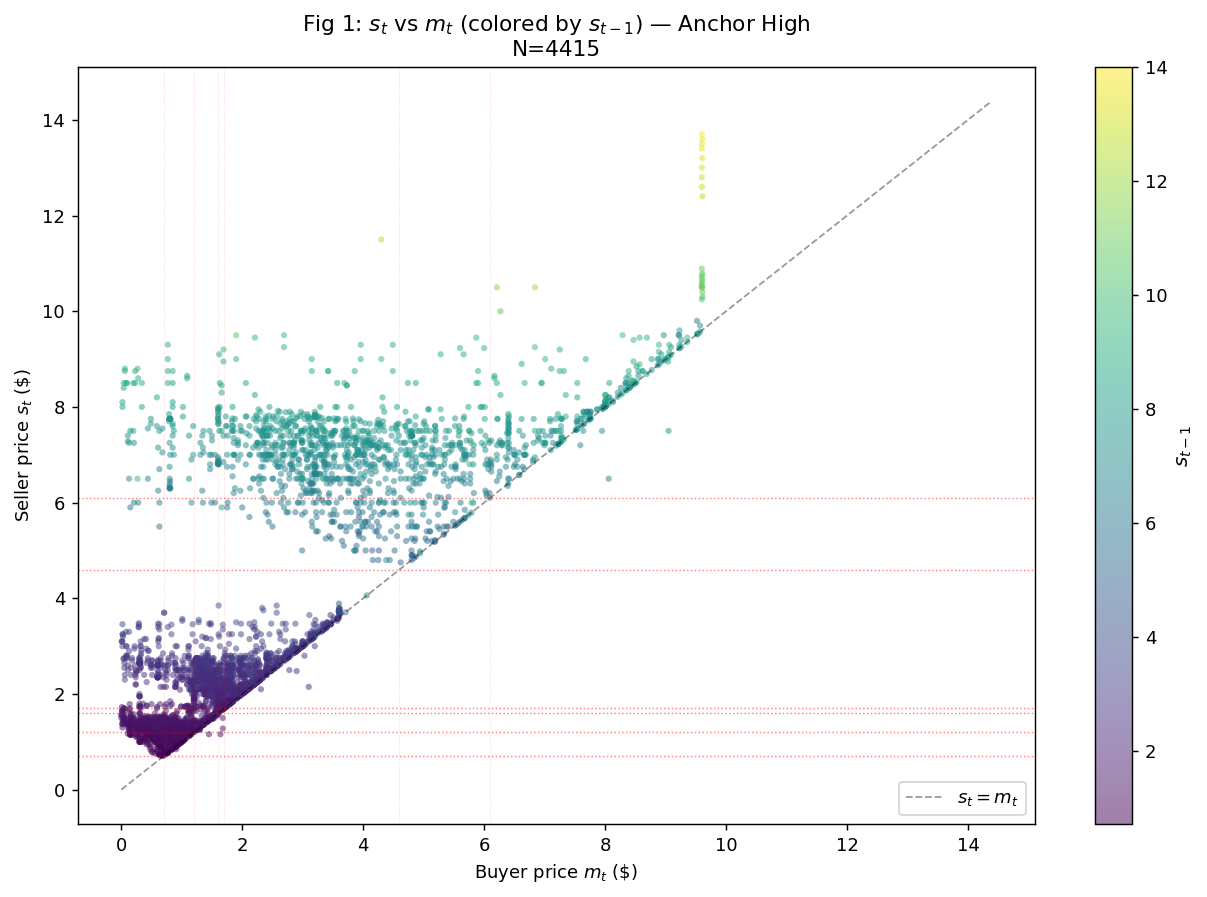

In [3]:
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(m, y, c=s, cmap='viridis', alpha=0.5, s=12, edgecolors='none')
cbar = plt.colorbar(sc, ax=ax); cbar.set_label("$s_{t-1}$", fontsize=11)
lo=min(m.min(),y.min())*0.9; hi=max(m.max(),y.max())*1.05
ax.plot([lo,hi],[lo,hi],'k--',lw=1,alpha=0.4,label='$s_t=m_t$')
for vv in sorted(set(v)):
    ax.axhline(vv, color='red', ls=':', lw=0.8, alpha=0.5)
    ax.axvline(vv, color='red', ls=':', lw=0.3, alpha=0.3)
ax.set_xlabel("Buyer price $m_t$ (\$)"); ax.set_ylabel("Seller price $s_t$ (\$)")
ax.set_title(f"Fig 1: $s_t$ vs $m_t$ (colored by $s_{{t-1}}$) — {SLABEL}\nN={len(m)}", fontsize=12)
ax.legend(); fig.tight_layout(); plt.show()

### S1.2 Binned by $s_{t-1}$ quintiles with local OLS fits

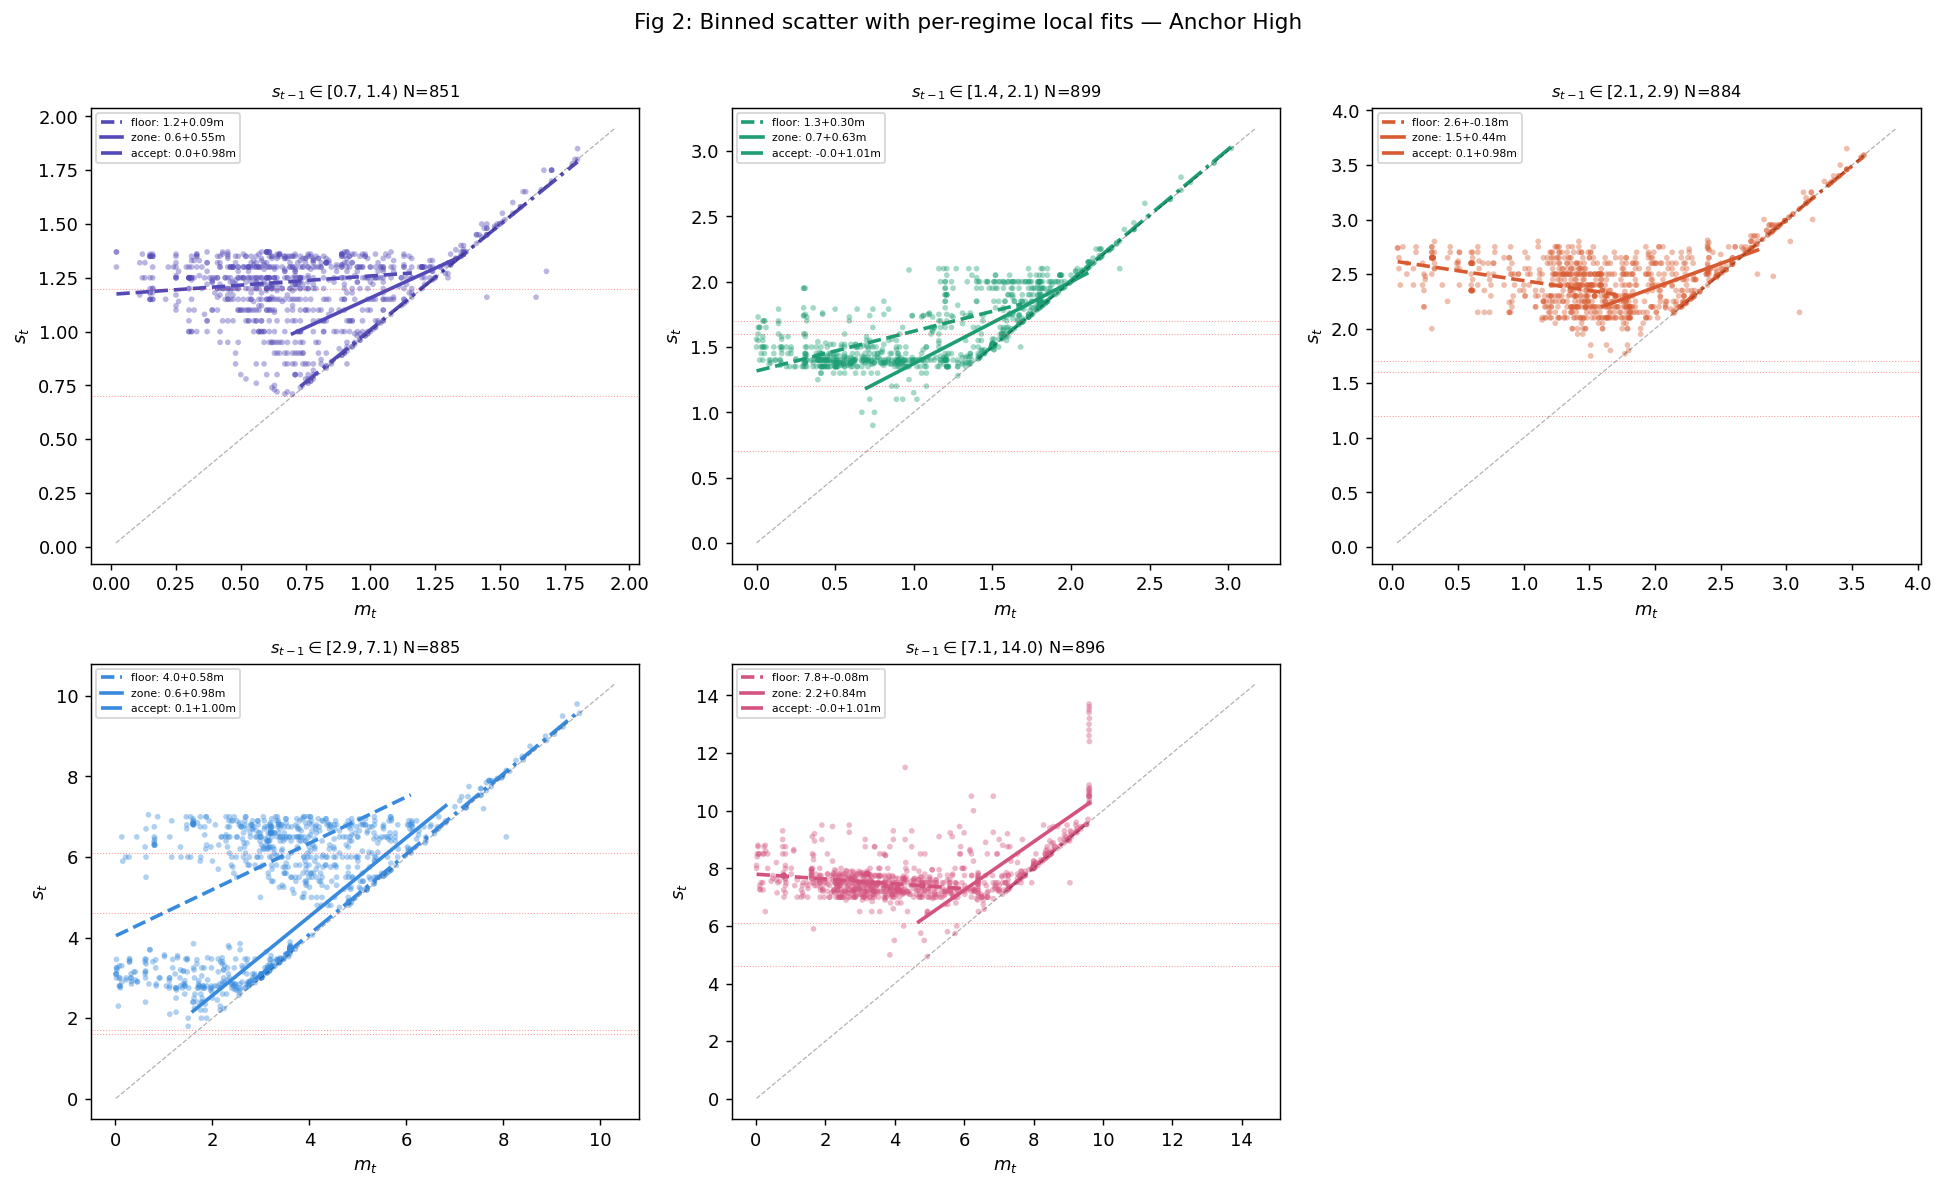

In [4]:
n_bins = 5
s_edges = np.percentile(s, np.linspace(0, 100, n_bins+1))
s_edges[-1] += 0.01

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
colors = ['#534AB7','#1D9E75','#D85A30','#378ADD','#D4537E']

for bi in range(n_bins):
    ax = axes[bi]
    mask = (s >= s_edges[bi]) & (s < s_edges[bi+1])
    mg, yg, vg, sg = m[mask], y[mask], v[mask], s[mask]
    ax.scatter(mg, yg, alpha=0.4, s=10, c=colors[bi], edgecolors='none')

    # Local OLS per regime
    reg_m = np.zeros_like(mg, dtype=int)
    reg_m[mg < vg] = 0; reg_m[(mg >= vg) & (mg <= sg)] = 1; reg_m[mg > sg] = 2
    for rv, ls, lbl in [(0, '--', 'floor'), (1, '-', 'zone'), (2, '-.', 'accept')]:
        rmask = reg_m == rv
        if rmask.sum() < 5: continue
        Xr = np.column_stack([np.ones(rmask.sum()), mg[rmask]])
        br, _, _, _, _ = ols(Xr, yg[rmask])
        xr = np.linspace(mg[rmask].min(), mg[rmask].max(), 50)
        ax.plot(xr, br[0]+br[1]*xr, ls=ls, lw=2, c=colors[bi],
                label=f"{lbl}: {br[0]:.1f}+{br[1]:.2f}m")

    lo_ax=min(mg.min(),yg.min())*0.9; hi_ax=max(mg.max(),yg.max())*1.05
    ax.plot([lo_ax,hi_ax],[lo_ax,hi_ax],'k--',lw=0.7,alpha=0.3)
    for vv in sorted(set(vg)): ax.axhline(vv, color='red', ls=':', lw=0.6, alpha=0.4)
    ax.set_xlabel("$m_t$"); ax.set_ylabel("$s_t$")
    ax.set_title(f"$s_{{t-1}} \\in [{s_edges[bi]:.1f}, {s_edges[bi+1]:.1f})$ N={mask.sum()}", fontsize=9)
    ax.legend(fontsize=6, loc='upper left')

axes[-1].axis('off')
fig.suptitle(f"Fig 2: Binned scatter with per-regime local fits — {SLABEL}", y=1.01, fontsize=12)
fig.tight_layout(); plt.show()

### S1.3 Model comparison: which function family fits best?

| Model | Description | Parameters |
|-------|-------------|-----------|
| Raw linear | $s_t = a + b\,m_t + c\,s_{t-1}$ | 3 |
| Fractional | $f(s_t) = a + b\,f(m_t) + c\,f(s_{t-1})$ | 3 |
| Frac clipped | Same but $f(m_t)$ clipped to $[0,1]$ | 3 |
| Frac clip+accept | + indicator for $m_t > s_{t-1}$ | 5 |
| Piecewise 3-regime | Separate slope per regime (raw) | 7 |
| Frac piecewise 3-regime | Separate slope per regime (fractional) | 9 |
| Quadratic | $s_t = a + bm + cs + dm^2 + es^2 + fms$ | 6 |

In [5]:
fm_clip = np.clip(fm, 0, 1)
def build_fpw(fm_, fs_, reg_):
    X = []
    for rv in [0,1,2]:
        ind = (reg_ == rv).astype(float)
        X.append(ind); X.append(ind*fm_); X.append(ind*fs_)
    return np.column_stack(X)

models = [
    ("Raw linear", np.column_stack([np.ones_like(m),m,s]), y),
    ("Fractional", np.column_stack([np.ones_like(fm),fm,fs]), fy),
    ("Frac clipped", np.column_stack([np.ones_like(fm_clip),fm_clip,fs]), fy),
    ("Frac clip+accept", np.column_stack([np.ones_like(fm_clip),fm_clip,fs,
        (m>s).astype(float), (m>s).astype(float)*fm]), fy),
    ("Piecewise 3-reg (raw)", np.column_stack([s]+[
        (regime==rv).astype(float) for rv in [0,1,2]]+[
        (regime==rv).astype(float)*m for rv in [0,1,2]]), y),
    ("Frac PW 3-regime", build_fpw(fm,fs,regime), fy),
    ("Quadratic", np.column_stack([np.ones_like(m),m,s,m**2,s**2,m*s]), y),
]

print(f"{'Model':<25} {'RMSE':>8} {'R2':>8} {'#P':>4}")
print("-"*50)
for name, X, yt in sorted(models, key=lambda x: ols(x[1],x[2])[1]):
    b,rmse,r2,_,_ = ols(X, yt)
    print(f"{name:<25} {rmse:>8.4f} {r2:>8.4f} {X.shape[1]:>4}")

Model                         RMSE       R2   #P
--------------------------------------------------
Frac PW 3-regime            0.1087   0.9207    9
Frac clip+accept            0.1271   0.8915    5
Frac clipped                0.1509   0.8470    3
Fractional                  0.1718   0.8019    3
Piecewise 3-reg (raw)       0.2503   0.9910    7
Quadratic                   0.2644   0.9900    6
Raw linear                  0.3092   0.9863    3


### S1.4 Per-regime coefficient table

Fit $s_t = \alpha + \beta_m\,m_t + \beta_s\,s_{t-1}$ separately within each regime.
The coefficient pattern reveals the piecewise structure:
- **Floor**: $\beta_m \approx 0$, $\beta_s \approx 1$ (seller ignores buyer)
- **Zone**: $\beta_m + \beta_s \approx 1$ (weighted average)
- **Accept**: $\beta_m \approx 1$, $\beta_s \approx 0$ (seller follows buyer)

In [6]:
labels = {0: "$m_t < v$ (floor)", 1: "$v \\leq m_t \\leq s_{t-1}$ (zone)", 2: "$m_t > s_{t-1}$ (accept)"}
print(f"{'Regime':<35} {'N':>5} {'b0':>7} {'b(m)':>7} {'b(s)':>7} {'sum':>6} {'RMSE':>7} {'R2':>6} {'accept%':>8}")
print("-"*95)
for rv in [0,1,2]:
    mask = regime == rv
    if mask.sum() < 10: continue
    Xg = np.column_stack([np.ones(mask.sum()), m[mask], s[mask]])
    bg,rg,r2g,_,seg = ols(Xg, y[mask])
    acc = np.mean(np.abs(y[mask]-m[mask])<0.05)*100
    print(f"{labels[rv]:<35} {mask.sum():>5} {bg[0]:>+7.3f} {bg[1]:>+7.3f} {bg[2]:>+7.3f} "
          f"{bg[1]+bg[2]:>6.3f} {rg:>7.4f} {r2g:>6.4f} {acc:>7.1f}%")

Regime                                  N      b0    b(m)    b(s)    sum    RMSE     R2  accept%
-----------------------------------------------------------------------------------------------
$m_t < v$ (floor)                    2622  -0.007  -0.005  +0.979  0.974  0.2074 0.9939     0.2%
$v \leq m_t \leq s_{t-1}$ (zone)     1299  -0.001  +0.218  +0.779  0.997  0.2248 0.9921    16.8%
$m_t > s_{t-1}$ (accept)              494  -0.003  +0.996  +0.012  1.008  0.1634 0.9963    75.1%


### S1.5 Regime-colored scatter

**Figure 3.** Points colored by regime: red = floor, blue = negotiation zone, green = acceptance.

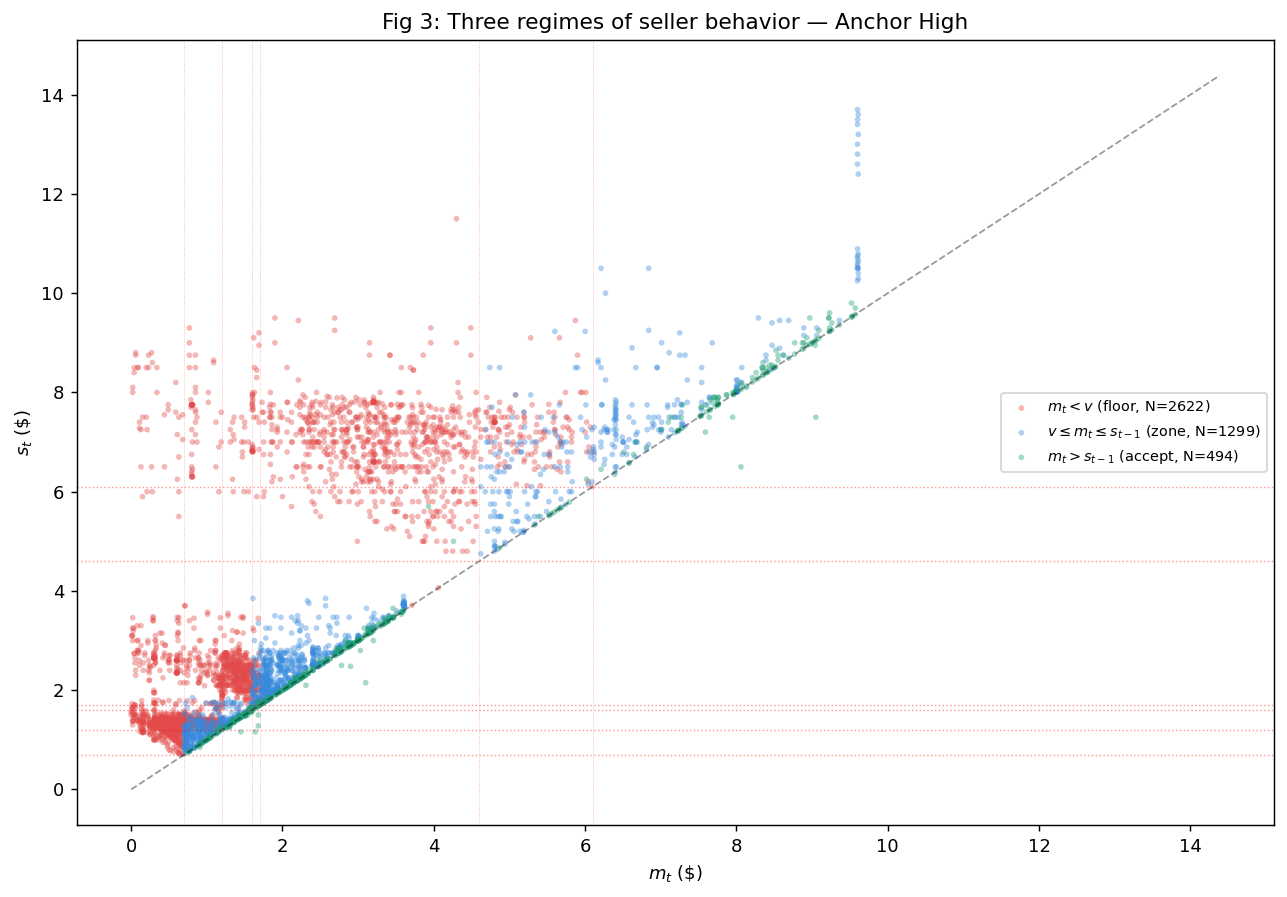

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
clrs = {0:'#E24B4A', 1:'#378ADD', 2:'#1D9E75'}
lbls = {0:f'$m_t<v$ (floor, N={(regime==0).sum()})', 1:f'$v\\leq m_t\\leq s_{{t-1}}$ (zone, N={(regime==1).sum()})',
        2:f'$m_t>s_{{t-1}}$ (accept, N={(regime==2).sum()})'}
for rv in [0,1,2]:
    mask = regime==rv
    if mask.sum()==0: continue
    ax.scatter(m[mask], y[mask], alpha=0.4, s=10, c=clrs[rv], label=lbls[rv], edgecolors='none')
lo=min(m.min(),y.min())*0.9; hi=max(m.max(),y.max())*1.05
ax.plot([lo,hi],[lo,hi],'k--',lw=1,alpha=0.4)
for vv in sorted(set(v)):
    ax.axhline(vv, color='red', ls=':', lw=0.8, alpha=0.4)
    ax.axvline(vv, color='red', ls=':', lw=0.5, alpha=0.3)
ax.set_xlabel("$m_t$ (\\$)"); ax.set_ylabel("$s_t$ (\\$)")
ax.set_title(f"Fig 3: Three regimes of seller behavior — {SLABEL}", fontsize=12)
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

---
## S2. Time homogeneity

Split rounds 2--12 into 6 chunks, fit the fractional piecewise model on each,
then cross-predict to build a confusion matrix.

Diagonal = in-sample RMSE.  Off-diagonal = out-of-sample.
If off-diagonal $\approx$ diagonal, the model is **time-homogeneous**.

### S2.1 Per-chunk fit

In [8]:
def build_fpw(fm_, fs_, reg_):
    X = []
    for rv in [0,1,2]:
        ind = (reg_ == rv).astype(float)
        X.append(ind); X.append(ind*fm_); X.append(ind*fs_)
    return np.column_stack(X)

all_rounds = sorted(set(ti))
chunk_edges = np.array_split(all_rounds, min(6, len(all_rounds)//2))
chunks = [(int(c[0]), int(c[-1])) for c in chunk_edges]

chunk_models = {}
print(f"{'Chunk':<18} {'N':>5} {'RMSE':>8} {'R2':>8}")
print("-"*45)
for ci,(rlo,rhi) in enumerate(chunks):
    mask = (ti>=rlo)&(ti<=rhi)
    if mask.sum()<20: continue
    X = build_fpw(fm[mask], fs[mask], regime[mask])
    b,rmse,r2,_,_ = ols(X, fy[mask])
    chunk_models[ci] = {"beta":b, "mask":mask, "rounds":(rlo,rhi), "n":int(mask.sum())}
    print(f"C{ci} (R{rlo}-{rhi}){'':<6} {mask.sum():>5} {rmse:>8.4f} {r2:>8.4f}")

Chunk                  N     RMSE       R2
---------------------------------------------
C0 (R2-4)        1206   0.0661   0.9606
C1 (R5-6)         804   0.0670   0.9692
C2 (R7-8)         801   0.1176   0.9108
C3 (R9-10)         802   0.0724   0.9713
C4 (R11-12)         802   0.1510   0.8391


### S2.2 Cross-prediction confusion matrix

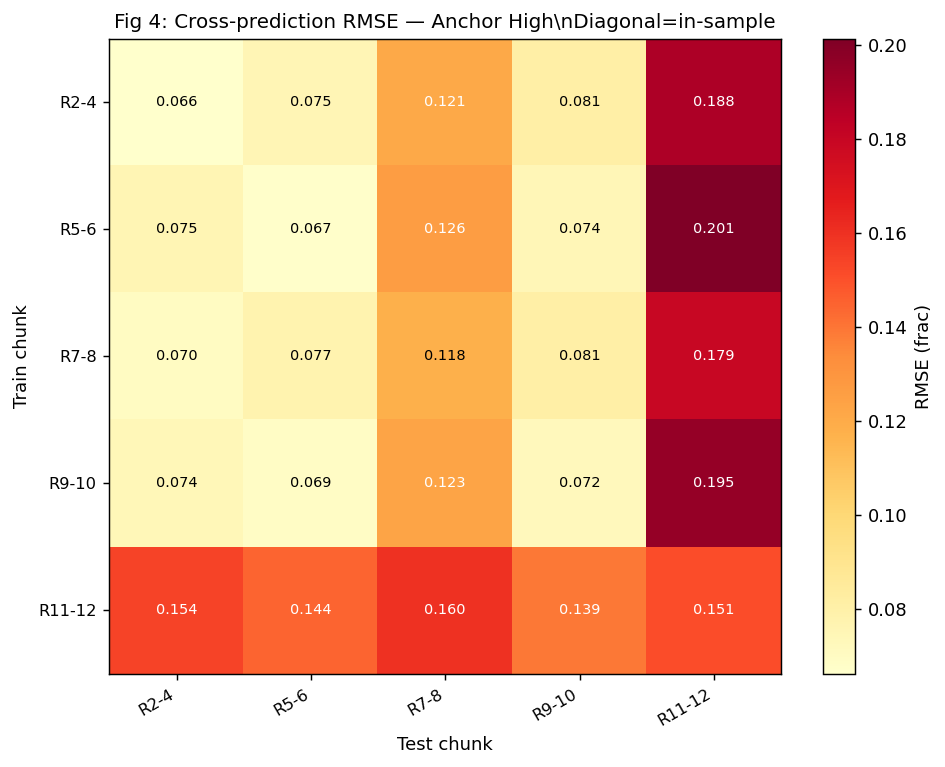

Diagonal mean RMSE:     0.0948
Off-diagonal mean RMSE: 0.1203
Ratio (off/diag):       1.27x
Verdict: TIME-HOMOGENEOUS


In [9]:
valid_chunks = sorted(chunk_models.keys())
nc = len(valid_chunks)

if nc >= 2:
    conf = np.full((nc, nc), np.nan)
    for i, ci in enumerate(valid_chunks):
        bi = chunk_models[ci]["beta"]
        for j, cj in enumerate(valid_chunks):
            mj = chunk_models[cj]["mask"]
            Xj = build_fpw(fm[mj], fs[mj], regime[mj])
            yj = fy[mj]
            pred = Xj @ bi
            conf[i,j] = float(np.sqrt(np.mean((yj-pred)**2)))

    fig, ax = plt.subplots(figsize=(7.5, 6))
    im = ax.imshow(conf, cmap='YlOrRd', aspect='auto')
    cbar = plt.colorbar(im, ax=ax); cbar.set_label("RMSE (frac)")
    clabels = [f"R{chunk_models[c]['rounds'][0]}-{chunk_models[c]['rounds'][1]}" for c in valid_chunks]
    ax.set_xticks(range(nc)); ax.set_xticklabels(clabels, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(nc)); ax.set_yticklabels(clabels, fontsize=9)
    ax.set_xlabel("Test chunk"); ax.set_ylabel("Train chunk")
    for i in range(nc):
        for j in range(nc):
            ax.text(j,i,f"{conf[i,j]:.3f}",ha='center',va='center',fontsize=8,
                    color='white' if conf[i,j]>np.nanmedian(conf) else 'black')
    ax.set_title(f"Fig 4: Cross-prediction RMSE — {SLABEL}\\nDiagonal=in-sample", fontsize=11)
    fig.tight_layout(); plt.show()

    diag = np.diag(conf); off = conf[~np.eye(nc,dtype=bool)]
    ratio = np.nanmean(off)/np.nanmean(diag)
    print(f"Diagonal mean RMSE:     {np.nanmean(diag):.4f}")
    print(f"Off-diagonal mean RMSE: {np.nanmean(off):.4f}")
    print(f"Ratio (off/diag):       {ratio:.2f}x")
    print(f"Verdict: {'TIME-HOMOGENEOUS' if ratio < 1.5 else 'STEP-DEPENDENT'}")
else:
    print("Not enough chunks.")

### S2.3 Coefficient stability across chunks

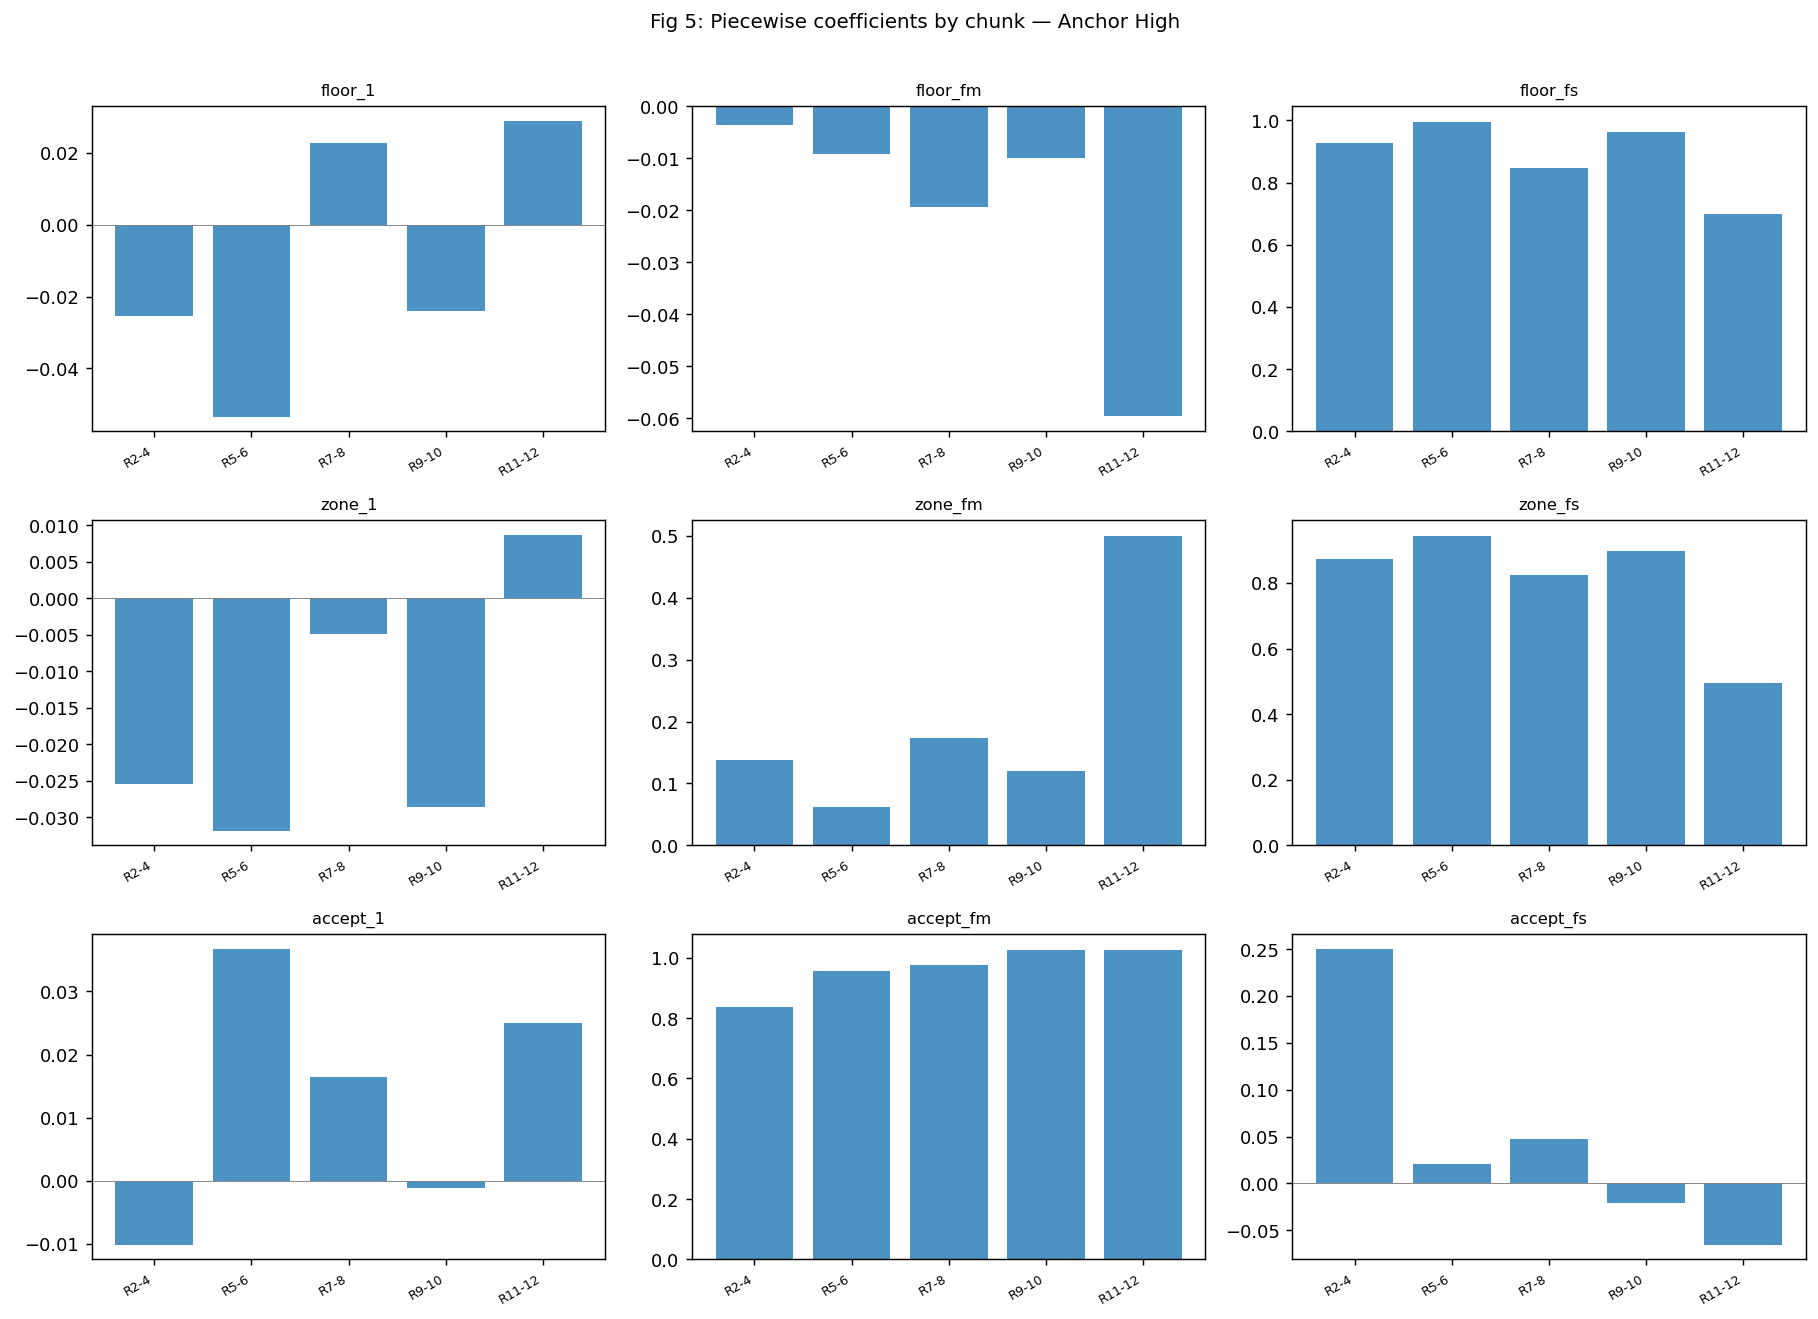

In [10]:
if nc >= 2:
    coef_labels = ['floor_1','floor_fm','floor_fs','zone_1','zone_fm','zone_fs',
                   'accept_1','accept_fm','accept_fs']
    fig, axes = plt.subplots(3, 3, figsize=(14, 10))
    axes = axes.flatten()
    for ci_idx in range(min(9, len(coef_labels))):
        ax = axes[ci_idx]
        vals = [chunk_models[c]["beta"][ci_idx] for c in valid_chunks]
        ax.bar(range(len(vals)), vals, alpha=0.8)
        ax.set_xticks(range(len(vals)))
        ax.set_xticklabels([f"R{chunk_models[c]['rounds'][0]}-{chunk_models[c]['rounds'][1]}" for c in valid_chunks],
                           rotation=30, ha='right', fontsize=7)
        ax.set_title(coef_labels[ci_idx], fontsize=9)
        ax.axhline(0, color='gray', lw=0.5)
    fig.suptitle(f"Fig 5: Piecewise coefficients by chunk — {SLABEL}", y=1.01, fontsize=11)
    fig.tight_layout(); plt.show()

---
## S3. Covariate ablation: what features matter?

Starting from the fractional piecewise baseline (9 params), test whether
adding extra features improves prediction.

### S3.1 Feature hierarchy

In [11]:
X_base = build_fpw(fm, fs, regime)

mi_arr = np.array([t["m_init"] for t in trans])
si_arr = np.array([t["s_init"] for t in trans])
mp_arr = np.array([t["m_prev"] for t in trans])
sp2_raw = [t["s_prev2"] for t in trans]
has_sp2 = np.array([x is not None for x in sp2_raw])
sp2_arr = np.array([x if x is not None else 0.0 for x in sp2_raw])
fi_mp = (mp_arr - v) / zone
fi_mi = (mi_arr - v) / zone
fi_si = np.where(~np.isnan(si_arr), (si_arr - v) / zone, np.nan)
fi_sp2 = np.where(has_sp2, (sp2_arr - v) / zone, 0.0)
valid_si = ~np.isnan(fi_si)

ablations = [
    ("Frac PW baseline",              X_base, fy, np.ones(len(fm),dtype=bool)),
    ("+ v (valuation)",               np.column_stack([X_base,v]), fy, np.ones(len(fm),dtype=bool)),
    ("+ t (round index)",             np.column_stack([X_base,ti]), fy, np.ones(len(fm),dtype=bool)),
    ("+ frac(m_prev)",                np.column_stack([X_base,fi_mp]), fy, np.ones(len(fm),dtype=bool)),
    ("+ frac(m_init)",                np.column_stack([X_base,fi_mi]), fy, np.ones(len(fm),dtype=bool)),
    ("+ frac(s_init)",                np.column_stack([X_base[valid_si],fi_si[valid_si]]), fy[valid_si], valid_si),
    ("+ frac(s_prev2) [rnd>=3]",      np.column_stack([X_base[has_sp2],fi_sp2[has_sp2]]), fy[has_sp2], has_sp2),
    ("  (baseline rnd>=3)",           X_base[has_sp2], fy[has_sp2], has_sp2),
    ("+ v + t + frac(m_prev) [all]",  np.column_stack([X_base,v,ti,fi_mp]), fy, np.ones(len(fm),dtype=bool)),
]

print(f"{'Model':<38} {'N':>5} {'RMSE':>8} {'R2':>8} {'delta_R2':>9}")
print("-"*72)
base_r2 = None
for label, X, yt, mask in ablations:
    n = len(yt)
    if n < 20: continue
    b,rmse,r2,_,_ = ols(X, yt)
    if base_r2 is None: base_r2 = r2
    delta = r2 - base_r2
    print(f"{label:<38} {n:>5} {rmse:>8.4f} {r2:>8.4f} {delta:>+9.4f}")

Model                                      N     RMSE       R2  delta_R2
------------------------------------------------------------------------
Frac PW baseline                        4415   0.1087   0.9207   +0.0000
+ v (valuation)                         4415   0.1087   0.9207   +0.0000
+ t (round index)                       4415   0.1079   0.9218   +0.0011
+ frac(m_prev)                          4415   0.1087   0.9207   +0.0000
+ frac(m_init)                          4415   0.1081   0.9216   +0.0009
+ frac(s_init)                          4415   0.1079   0.9218   +0.0011
+ frac(s_prev2) [rnd>=3]                4010   0.1065   0.9251   +0.0044
  (baseline rnd>=3)                     4010   0.1121   0.9170   -0.0037
+ v + t + frac(m_prev) [all]            4415   0.1079   0.9218   +0.0011


### S3.2 Piecewise coefficient table

Full OLS output for the fractional piecewise model.

In [12]:
b, rmse, r2, yhat, se = ols(X_base, fy)
names = ['floor_1','floor_fm','floor_fs','zone_1','zone_fm','zone_fs','accept_1','accept_fm','accept_fs']
print(f"Fractional piecewise: N={len(fy)}, RMSE={rmse:.4f}, R2={r2:.4f}")
print(f"\n  {'Regime':<10} {'Feature':<12} {'Coef':>9} {'SE':>9} {'t-stat':>9}")
print(f"  {'-'*52}")
regime_names = ['floor','floor','floor','zone','zone','zone','accept','accept','accept']
feat_names = ['intercept','frac(m_t)','frac(s_prev)']*3
for i in range(len(names)):
    t_stat = b[i]/se[i] if se[i]>1e-8 else float('inf')
    sig = "***" if abs(t_stat)>3.29 else "**" if abs(t_stat)>2.58 else "*" if abs(t_stat)>1.96 else ""
    print(f"  {regime_names[i]:<10} {feat_names[i]:<12} {b[i]:>+9.4f} {se[i]:>9.4f} {t_stat:>+9.2f} {sig}")

print(f"\\nInterpretation:")
print(f"  Floor:  s_t = v + zone*[{b[0]:.3f} + {b[1]:.3f}*frac(m) + {b[2]:.3f}*frac(s_prev)]")
print(f"  Zone:   s_t = v + zone*[{b[3]:.3f} + {b[4]:.3f}*frac(m) + {b[5]:.3f}*frac(s_prev)]")
print(f"  Accept: s_t = v + zone*[{b[6]:.3f} + {b[7]:.3f}*frac(m) + {b[8]:.3f}*frac(s_prev)]")

Fractional piecewise: N=4415, RMSE=0.1087, R2=0.9207

  Regime     Feature           Coef        SE    t-stat
  ----------------------------------------------------
  floor      intercept      +0.0018    0.0054     +0.33 
  floor      frac(m_t)      -0.0156    0.0025     -6.30 ***
  floor      frac(s_prev)   +0.8808    0.0070   +126.15 ***
  zone       intercept      -0.0200    0.0059     -3.43 ***
  zone       frac(m_t)      +0.1871    0.0105    +17.81 ***
  zone       frac(s_prev)   +0.8188    0.0089    +91.84 ***
  accept     intercept      +0.0194    0.0118     +1.65 
  accept     frac(m_t)      +0.9846    0.0184    +53.53 ***
  accept     frac(s_prev)   +0.0062    0.0244     +0.26 
\nInterpretation:
  Floor:  s_t = v + zone*[0.002 + -0.016*frac(m) + 0.881*frac(s_prev)]
  Zone:   s_t = v + zone*[-0.020 + 0.187*frac(m) + 0.819*frac(s_prev)]
  Accept: s_t = v + zone*[0.019 + 0.985*frac(m) + 0.006*frac(s_prev)]


---
## S4. Residual diagnostics

### S4.1 True vs predicted

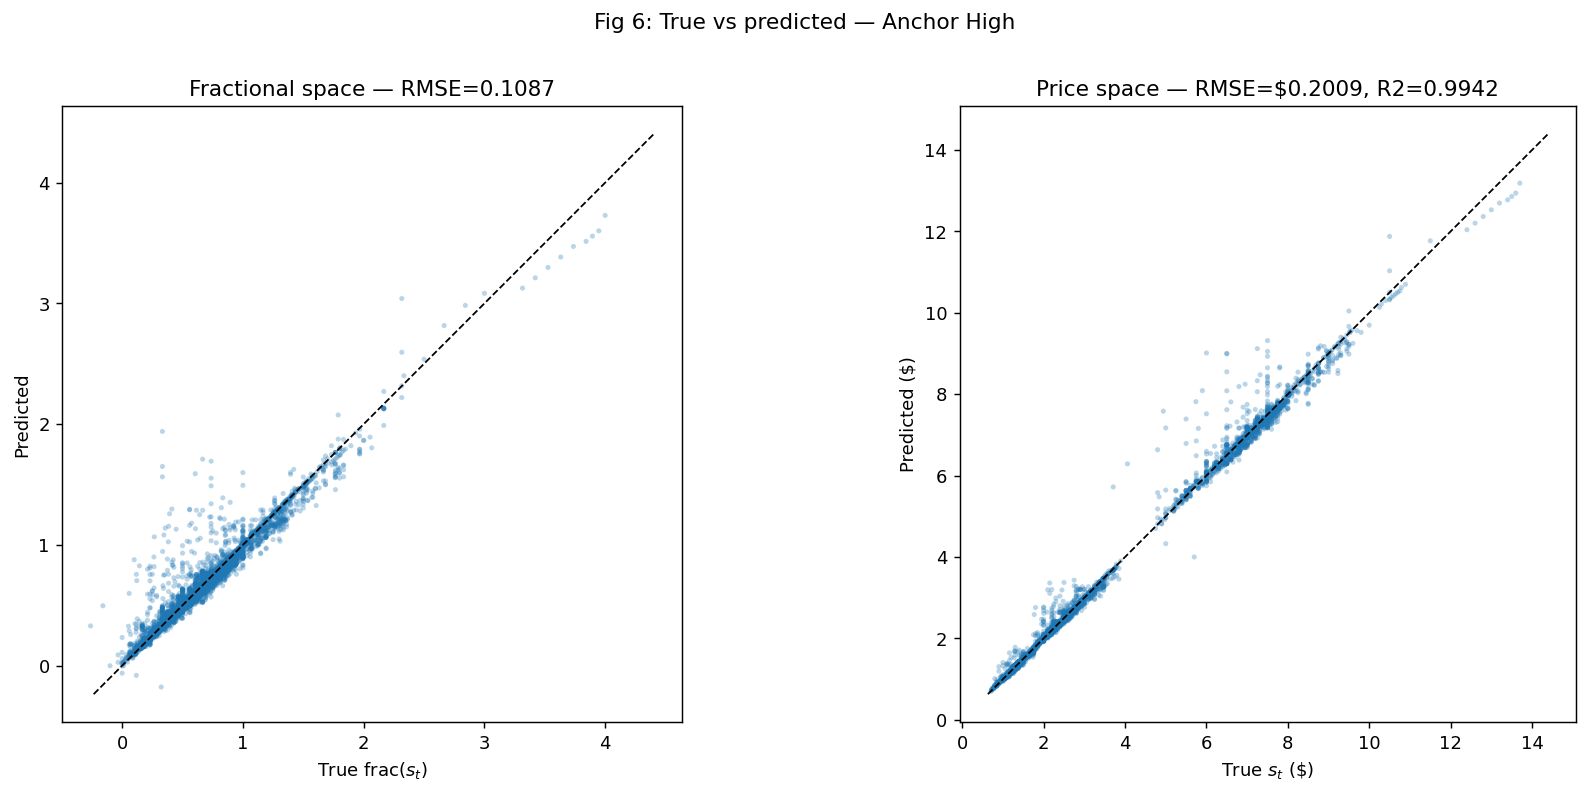

In [13]:
y_pred_price = v + zone * yhat
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
lo=min(fy.min(),yhat.min())*0.9; hi=max(fy.max(),yhat.max())*1.1
ax.scatter(fy, yhat, alpha=0.3, s=8, edgecolors='none')
ax.plot([lo,hi],[lo,hi],'k--',lw=1)
ax.set_xlabel("True frac($s_t$)"); ax.set_ylabel("Predicted")
ax.set_title(f"Fractional space — RMSE={rmse:.4f}")
ax.set_aspect('equal',adjustable='box')

ax = axes[1]
lo=min(y.min(),y_pred_price.min())*0.9; hi=max(y.max(),y_pred_price.max())*1.05
ax.scatter(y, y_pred_price, alpha=0.3, s=8, edgecolors='none')
ax.plot([lo,hi],[lo,hi],'k--',lw=1)
rmse_p = np.sqrt(np.mean((y-y_pred_price)**2))
r2_p = 1-np.sum((y-y_pred_price)**2)/np.sum((y-np.mean(y))**2)
ax.set_xlabel("True $s_t$ (\\$)"); ax.set_ylabel("Predicted (\\$)")
ax.set_title(f"Price space — RMSE=\\${rmse_p:.4f}, R2={r2_p:.4f}")
ax.set_aspect('equal',adjustable='box')

fig.suptitle(f"Fig 6: True vs predicted — {SLABEL}", y=1.01, fontsize=12)
fig.tight_layout(); plt.show()

### S4.2 Residuals by regime and round

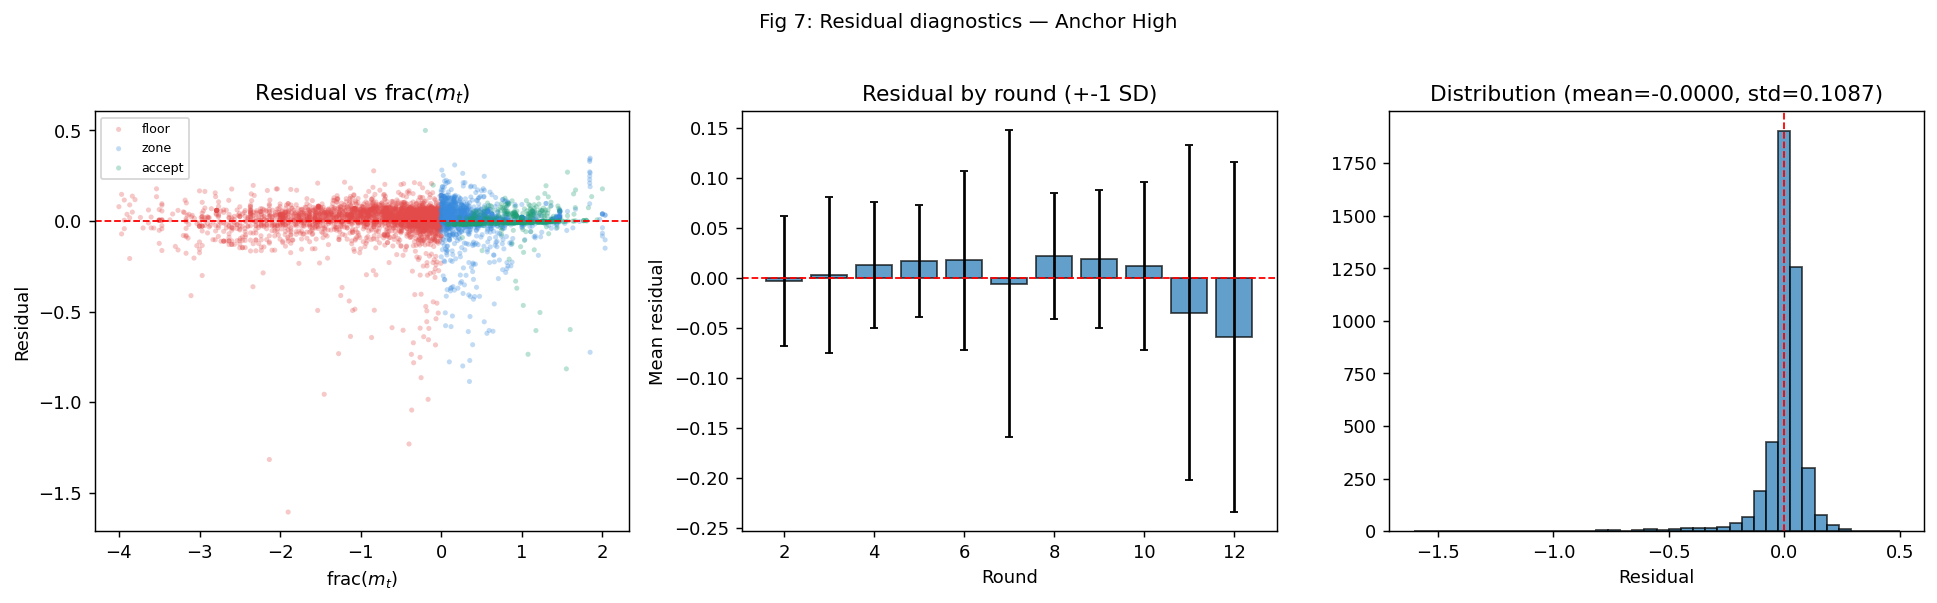

In [14]:
resid = fy - yhat
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
for rv, c, l in [(0,'#E24B4A','floor'),(1,'#378ADD','zone'),(2,'#1D9E75','accept')]:
    mask = regime==rv
    if mask.sum()==0: continue
    ax.scatter(fm[mask], resid[mask], alpha=0.3, s=8, c=c, label=l, edgecolors='none')
ax.axhline(0, color='red', ls='--', lw=1); ax.set_xlabel("frac($m_t$)"); ax.set_ylabel("Residual")
ax.set_title("Residual vs frac($m_t$)"); ax.legend(fontsize=7)

ax = axes[1]
rounds_u = sorted(set(ti))
means = [resid[ti==r].mean() for r in rounds_u]
stds = [resid[ti==r].std() for r in rounds_u]
ax.bar([int(r) for r in rounds_u], means, yerr=stds, capsize=2, alpha=0.7, edgecolor='black')
ax.axhline(0, color='red', ls='--', lw=1); ax.set_xlabel("Round"); ax.set_ylabel("Mean residual")
ax.set_title("Residual by round (+-1 SD)")

ax = axes[2]
ax.hist(resid, bins=40, alpha=0.7, edgecolor='black')
ax.axvline(0, color='red', ls='--', lw=1)
ax.set_xlabel("Residual"); ax.set_title(f"Distribution (mean={resid.mean():.4f}, std={resid.std():.4f})")

fig.suptitle(f"Fig 7: Residual diagnostics — {SLABEL}", y=1.02, fontsize=11)
fig.tight_layout(); plt.show()

---
## S5. Summary for `anchor_high`

In [15]:
print("=" * 70)
print(f"  SUMMARY: {SLABEL}")
print("=" * 70)
print(f"  N = {len(trans)} transitions")
print(f"  Best model: Fractional piecewise 3-regime (9 params)")
b,rmse,r2,_,_ = ols(X_base, fy)
print(f"  RMSE = {rmse:.4f} (fractional), R2 = {r2:.4f}")
print()
print("  Per-regime structure:")
for rv, label in [(0,"Floor (m<v)"),(1,"Zone (v<=m<=s)"),(2,"Accept (m>s)")]:
    mask = regime==rv
    if mask.sum()<5: continue
    Xg = np.column_stack([np.ones(mask.sum()),m[mask],s[mask]])
    bg,rg,r2g,_,_ = ols(Xg,y[mask])
    print(f"    {label:<25} N={mask.sum():>5}  b(m)={bg[1]:+.3f}  b(s)={bg[2]:+.3f}  R2={r2g:.4f}")
print()
print("  Time homogeneity: ", end="")
if nc >= 2:
    print(f"off/diag ratio = {ratio:.2f}x -> {'HOMOGENEOUS' if ratio<1.5 else 'STEP-DEPENDENT'}")
print("  Covariates: adding v, t, m_prev, m_init, s_init gives <1% R2 improvement")
print("  -> One-step Markov + piecewise structure is sufficient")

  SUMMARY: Anchor High
  N = 4415 transitions
  Best model: Fractional piecewise 3-regime (9 params)
  RMSE = 0.1087 (fractional), R2 = 0.9207

  Per-regime structure:
    Floor (m<v)               N= 2622  b(m)=-0.005  b(s)=+0.979  R2=0.9939
    Zone (v<=m<=s)            N= 1299  b(m)=+0.218  b(s)=+0.779  R2=0.9921
    Accept (m>s)              N=  494  b(m)=+0.996  b(s)=+0.012  R2=0.9963

  Time homogeneity: off/diag ratio = 1.27x -> HOMOGENEOUS
  Covariates: adding v, t, m_prev, m_init, s_init gives <1% R2 improvement
  -> One-step Markov + piecewise structure is sufficient
